### Модуль дообучения модели для задачи распознавания степени утомления

In [1]:
import numpy as np
import tensorflow as tf
import librosa
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tqdm import tqdm
from pathlib import Path
import os


class MacroF1(tf.keras.metrics.Metric):
    def __init__(self, num_classes=3, name="macro_f1", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.true_positives = self.add_weight(name="tp", shape=(num_classes,), initializer="zeros", dtype=tf.float32)
        self.false_positives = self.add_weight(name="fp", shape=(num_classes,), initializer="zeros", dtype=tf.float32)
        self.false_negatives = self.add_weight(name="fn", shape=(num_classes,), initializer="zeros", dtype=tf.float32)

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, [-1, self.num_classes]), tf.float32)
        y_pred = tf.cast(tf.reshape(y_pred, [-1, self.num_classes]), tf.float32)
        y_true_labels = tf.argmax(y_true, axis=-1)
        y_pred_labels = tf.argmax(y_pred, axis=-1)
        
        for i in range(self.num_classes):
            y_true_i = tf.equal(y_true_labels, i)
            y_pred_i = tf.equal(y_pred_labels, i)
            tp = tf.reduce_sum(tf.cast(tf.logical_and(y_true_i, y_pred_i), self.dtype))
            fp = tf.reduce_sum(tf.cast(tf.logical_and(tf.logical_not(y_true_i), y_pred_i), self.dtype))
            fn = tf.reduce_sum(tf.cast(tf.logical_and(y_true_i, tf.logical_not(y_pred_i)), self.dtype))
            
            updates_tp = tf.tensor_scatter_nd_add(self.true_positives, [[i]], [tp])
            updates_fp = tf.tensor_scatter_nd_add(self.false_positives, [[i]], [fp])
            updates_fn = tf.tensor_scatter_nd_add(self.false_negatives, [[i]], [fn])

            self.true_positives.assign(updates_tp)
            self.false_positives.assign(updates_fp)
            self.false_negatives.assign(updates_fn)

    def result(self):
        precision = tf.math.divide_no_nan(self.true_positives, self.true_positives + self.false_positives)
        recall = tf.math.divide_no_nan(self.true_positives, self.true_positives + self.false_negatives)
        f1 = tf.math.divide_no_nan(2 * precision * recall, precision + recall)
        macro_f1 = tf.reduce_mean(f1)
        return macro_f1

    def reset_states(self):
        self.true_positives.assign(tf.zeros_like(self.true_positives))
        self.false_positives.assign(tf.zeros_like(self.false_positives))
        self.false_negatives.assign(tf.zeros_like(self.false_negatives))



In [46]:
# Пути к данным
LABELED_DATA_PATH = "fatigue_all_features.npz"
SELECTED_INDICES_PATH = "fatigue_selected_18_indices.npy"
UNLABELED_AUDIO_PATH = "D:/Аудио выборка/fatigue_frames_denoised"  # папка с неразмеченными аудио
MODEL_PATH = "best_fatigue_model_18_b2.keras"
OUTPUT_MODEL_PATH = "best_fatigue_model_18_b2_semi_f.keras"

# Параметры полуконтролируемого обучения
CLASS_THRESHOLDS = {
    0: 0.87,  # нет утомления
    1: 0.81,  # слабое утомление (более низкий порог для привлечения большего числа примеров)
    2: 0.99   # сильное утомление
}
MAX_ITERATIONS = 2               # максимальное число итераций 2
SUPERVISED_EPOCHS = 14           # эпох дообучения на расширенном наборе 10
BATCH_SIZE = 20
LEARNING_RATE = 5e-6             # маленькая скорость для аккуратного дообучения
# Опционально: динамическое изменение порогов
DYNAMIC_THRESHOLD = True                 # увеличивать пороги с каждой итерацией
THRESHOLD_INCREMENT = 0.02               # шаг увеличения порога (не используется при динамическом изменении)
FINAL_CLASS_THRESHOLDS = {
    0: 0.905,  # финальный порог для класса 0
    1: 0.865,  # финальный порог для класса 1
    2: 0.995   # финальный порог для класса 2
}

# Параметры извлечения признаков (совпадают с обучением)
SR = 16000
HOP_LEN = 160
WIN_LEN = 400
N_MFCC = 13
MAX_LEN = 101

In [42]:
"""
Псевдо-разметка (Self-Training) для дообучения модели распознавания утомления
----------------------------------------------------------------------------
Использует неразмеченные данные для улучшения модели через итеративное добавление
уверенных псевдо-меток. Каждый неразмеченный пример добавляется в обучающую выборку
только один раз.
"""


def load_labeled_data(npz_path, selected_indices_path):
    """
    Загружает размеченные данные из .npz-файла и отбирает только выбранные признаки по указанным индексам.

    Аргументы:
        npz_path (str): Путь к .npz-файлу с размеченными данными.
        selected_indices_path (str): Путь к .npy-файлу с массивом индексов выбранных признаков.

    Возвращает:
        temporals (np.ndarray): Массив временных признаков с выбранными индексами, shape (n, 101, n_selected).
        handcrafted (np.ndarray): Массив ручных признаков (джиттер, шиммер), shape (n, 2).
        labels (np.ndarray): Массив меток классов, shape (n,).
        selected_indices (np.ndarray): Список выбранных индексов признаков.
    """
    data = np.load(npz_path, allow_pickle=True)
    
    temporals = data['temporals']      # (n, 101, 43)
    jitters = data['jitters']          # (n,)
    shimmers = data['shimmers']        # (n,)
    labels = data['labels']            # (n,)
    
    # Загружаем индексы выбранных признаков
    selected_indices = np.load(selected_indices_path)
    
    # Отбираем только выбранные признаки
    temporals = temporals[:, :, selected_indices]
    
    temporals = temporals.astype(np.float32)
    jitters = jitters.astype(np.float32)
    shimmers = shimmers.astype(np.float32)
    labels = labels.astype(np.int32)
    
    handcrafted = np.stack([jitters, shimmers], axis=1)
    
    print(f"Загружено размеченных образцов: {len(temporals)}")
    print(f"Размерность temporals: {temporals.shape}")
    print(f"Распределение классов: {np.bincount(labels)}")
    
    return temporals, handcrafted, labels, selected_indices


def split_and_normalize(temporals, handcrafted, labels, random_state=119):
    """
    Делит данные на train/val/test, и выполняет нормализацию признаков.

    Аргументы:
        temporals (np.ndarray): Массив временных признаков, shape (n, 101, n_selected).
        handcrafted (np.ndarray): Массив ручных признаков, shape (n, 2).
        labels (np.ndarray): Массив меток классов, shape (n,).
        random_state (int, optional): random seed для воспроизводимости. По умолчанию 119.

    Возвращает:
        dict: Словарь с нормализованными разбиениями:
            {
              'X_train' (np.ndarray): временные train,
              'X_val' (np.ndarray): временные val,
              'X_test' (np.ndarray): временные test,
              'H_train' (np.ndarray): ручные train,
              'H_val' (np.ndarray): ручные val,
              'H_test' (np.ndarray): ручные test,
              'y_train' (np.ndarray): метки train,
              'y_val' (np.ndarray): метки val,
              'y_test' (np.ndarray): метки test,
              'scaler_t' (StandardScaler): скейлер для временных признаков,
              'scaler_h' (StandardScaler): скейлер для ручных признаков
            }
    """

    X_train, X_temp, H_train, H_temp, y_train, y_temp = train_test_split(
        temporals, handcrafted, labels,
        test_size=0.3,
        stratify=labels,
        random_state=random_state
    )
    
    X_val, X_test, H_val, H_test, y_val, y_test = train_test_split(
        X_temp, H_temp, y_temp,
        test_size=0.5,
        stratify=y_temp,
        random_state=random_state
    )
    
    # Нормализация временных признаков
    scaler_t = StandardScaler()
    shape = X_train.shape
    X_train_flat = X_train.reshape(-1, shape[-1])
    X_train_norm = scaler_t.fit_transform(X_train_flat).reshape(shape)
    X_val_norm = scaler_t.transform(X_val.reshape(-1, shape[-1])).reshape(X_val.shape)
    X_test_norm = scaler_t.transform(X_test.reshape(-1, shape[-1])).reshape(X_test.shape)
    
    # Нормализация ручных признаков
    scaler_h = StandardScaler()
    H_train_norm = scaler_h.fit_transform(H_train)
    H_val_norm = scaler_h.transform(H_val)
    H_test_norm = scaler_h.transform(H_test)
    
    print(f"Разделение: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")
    
    return {
        'X_train': X_train_norm,
        'X_val': X_val_norm,
        'X_test': X_test_norm,
        'H_train': H_train_norm,
        'H_val': H_val_norm,
        'H_test': H_test_norm,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
        'scaler_t': scaler_t,
        'scaler_h': scaler_h
    }



def extract_full_temporal_features(audio):
    """
    Извлекает полный набор из 43 временных признаков для входного аудиосигнала.

    Признаки включают MFCC (13), дельты (13), дельты второго порядка (13),
    а также F0, RMS, HNR, ZCR на каждый из 101 временных кадров.

    Аргументы:
        audio (np.ndarray): Одномерный аудиосигнал.

    Возвращает:
        np.ndarray: Массив признаков shape (101, 43).
    """
    # Нормализация громкости
    if np.max(np.abs(audio)) > 0:
        audio = audio / np.max(np.abs(audio))
    
    mfcc = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=N_MFCC,
                                hop_length=HOP_LEN, n_fft=WIN_LEN)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    mfcc_features = np.vstack([mfcc, delta, delta2]).T  # (101, 39)
    
    f0, _, _ = librosa.pyin(audio, fmin=80, fmax=300, sr=SR,
                            hop_length=HOP_LEN, frame_length=450)
    f0 = np.nan_to_num(f0, nan=0.0)
    f0 = f0.reshape(-1, 1)
    
    rms = librosa.feature.rms(y=audio, hop_length=HOP_LEN, frame_length=WIN_LEN)[0]
    rms = rms.reshape(-1, 1)
    
    harmonic = librosa.effects.harmonic(y=audio, margin=4.0)
    noise = audio - harmonic
    e_h = float(np.mean(harmonic ** 2) + 1e-9)
    e_n = float(np.mean(noise ** 2) + 1e-9)
    hnr = np.full(101, 10.0 * np.log10(e_h / e_n)).reshape(-1, 1)
    
    zcr = librosa.feature.zero_crossing_rate(y=audio, hop_length=HOP_LEN, frame_length=WIN_LEN)[0]
    zcr = zcr.reshape(-1, 1)
    
    temporal = np.concatenate([mfcc_features, f0, rms, hnr, zcr], axis=1)  # Объединяем (101, 43)
    return temporal


def extract_unlabeled_features(file_path, selected_indices):
    """
    Извлекает признаки для неразмеченного аудиофайла, включая только выбранные по индексам временные признаки,
    а также вычисляет джиттер и шиммер.

    Аргументы:
        file_path (str): Путь до аудиофайла .wav.
        selected_indices (np.ndarray или list): Индексы отбираемых временных признаков (по столбцам).

    Возвращает:
        temporal (np.ndarray): Массив выбранных временных признаков, shape (101, n_selected), dtype float32.
        handcrafted (np.ndarray): Массив ручных признаков: [джиттер, шиммер], shape (2,), dtype float32.
        Если возникает ошибка — возвращает (None, None).
    """
    try:
        audio, _ = librosa.load(file_path, sr=SR)
        
        # Приведение к 1 секунде
        target_len = SR
        if len(audio) > target_len:
            audio = audio[:target_len]
        elif len(audio) < target_len:
            audio = np.pad(audio, (0, target_len - len(audio)), mode='constant')
        
        # Полные признаки (43)
        temporal_full = extract_full_temporal_features(audio)
        
        # Отбор по индексам
        temporal = temporal_full[:, selected_indices]  # (101, n_selected)
        
        # Джиттер и шиммер
        f0, voiced_flag, _ = librosa.pyin(audio, fmin=80, fmax=300, sr=SR,
                                          hop_length=HOP_LEN, frame_length=450)
        jitter, shimmer = 0.0, 0.0
        if voiced_flag is not None:
            voiced_flag = np.asarray(voiced_flag, dtype=bool)
            if np.count_nonzero(voiced_flag) > 0:
                periods = 1.0 / f0[voiced_flag]
                if len(periods) >= 3:
                    period_diffs = np.abs(np.diff(periods))
                    jitter = np.mean(period_diffs) / (np.mean(periods) + 1e-6)
                rms = librosa.feature.rms(y=audio, hop_length=HOP_LEN, frame_length=WIN_LEN)[0]
                voiced_idx = np.where(voiced_flag)[0]
                if len(voiced_idx) >= 3:
                    rms_voiced = rms[voiced_idx]
                    rms_diffs = np.abs(np.diff(rms_voiced))
                    shimmer = np.mean(rms_diffs) / (np.mean(rms_voiced) + 1e-6)
        
        handcrafted = np.array([jitter, shimmer], dtype=np.float32)
        temporal = temporal.astype(np.float32)
        
        return temporal, handcrafted
        
    except Exception as e:
        print(f"Ошибка при обработке {file_path}: {e}")
        return None, None


def load_unlabeled_data(unlabeled_path, selected_indices, max_samples=None):
    """
    Загружает неразмеченные аудиоданные из заданной директории, извлекает и возвращает признаки.

    Аргументы:
        unlabeled_path (str): Путь к папке с .wav аудиофайлами.
        selected_indices (np.ndarray или list): Индексы временных признаков для отбора.
        max_samples (int, optional): Максимальное количество файлов для загрузки.

    Возвращает:
        X_unlabeled (np.ndarray): Массив временных признаков для неразмеченных файлов, shape (n_unlabeled, 101, n_selected).
        H_unlabeled (np.ndarray): Массив ручных признаков для неразмеченных файлов, shape (n_unlabeled, 2).
    """
    
    audio_files = list(Path(unlabeled_path).glob("*.wav"))
    if max_samples:
        audio_files = audio_files[:max_samples]
    
    print(f"Загрузка неразмеченных данных из {unlabeled_path}")
    print(f"Найдено файлов: {len(audio_files)}")
    
    temporals = []
    handcrafteds = []
    
    for file_path in tqdm(audio_files, desc="Загрузка"):
        temporal, handcrafted = extract_unlabeled_features(str(file_path), selected_indices)
        if temporal is not None:
            temporals.append(temporal)
            handcrafteds.append(handcrafted)
    
    X_unlabeled = np.array(temporals, dtype=np.float32)
    H_unlabeled = np.array(handcrafteds, dtype=np.float32)
    
    print(f"Загружено неразмеченных: {len(X_unlabeled)}")
    print(f"  Временные признаки: {X_unlabeled.shape}")
    
    return X_unlabeled, H_unlabeled


def normalize_unlabeled_data(X_unlabeled, H_unlabeled, scaler_t, scaler_h):
    """
    Применяет обученные скейлеры для нормализации временных и ручных признаков неразмеченных данных.

    Аргументы:
        X_unlabeled (np.ndarray): Временные признаки для неразмеченных данных, shape (n, 101, n_selected).
        H_unlabeled (np.ndarray): Ручные признаки для неразмеченных данных, shape (n, 2).
        scaler_t (StandardScaler): Обученный скейлер для временных признаков.
        scaler_h (StandardScaler): Обученный скейлер для ручных признаков.

    Возвращает:
        tuple:
            X_norm (np.ndarray): Нормализованные временные признаки, shape как у X_unlabeled, dtype float32.
            H_norm (np.ndarray): Нормализованные ручные признаки, shape как у H_unlabeled, dtype float32.
    """
    shape = X_unlabeled.shape
    X_flat = X_unlabeled.reshape(-1, shape[-1])
    X_norm = scaler_t.transform(X_flat).reshape(shape)
    H_norm = scaler_h.transform(H_unlabeled)
    return X_norm.astype(np.float32), H_norm.astype(np.float32)


def fine_tune_model(model, X_train, H_train, y_train, X_val, H_val, y_val,
                    epochs=SUPERVISED_EPOCHS, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE):
    """
    Дообучает (fine-tune) переданную модель на расширенном (обычно semi-supervised) наборе данных.

    Аргументы:
        model (tf.keras.Model): Компилируемая и обучаемая модель Keras.
        X_train (np.ndarray): Массив временных признаков обучающей выборки, shape (n_train, 101, n_selected).
        H_train (np.ndarray): Массив ручных признаков обучающей выборки, shape (n_train, 2).
        y_train (np.ndarray): Метки классов для обучающей выборки.
        X_val (np.ndarray): Массив временных признаков валидационной выборки.
        H_val (np.ndarray): Массив ручных признаков валидационной выборки.
        y_val (np.ndarray): Метки классов для валидации.
        epochs (int, optional): Количество эпох дообучения.
        batch_size (int, optional): Размер батча.
        learning_rate (float, optional): Скорость обучения.

    Возвращает:
        history (tf.keras.callbacks.History): Объект с историей обучения модели.
    """
    
    y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=3)
    y_val_cat = tf.keras.utils.to_categorical(y_val, num_classes=3)
    
    # Веса классов
    class_weight_dict = {0: 0.75, 1: 1.7, 2: 2.1} #{0: 0.7, 1: 1.7, 2: 2.3}

    macro_f1 = MacroF1(num_classes=3)
    # Компиляция с маленькой скоростью обучения
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy', 'precision', 'recall', 'auc', macro_f1]
    )
    
    # Ранняя остановка
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
    
    # Обучение
    history = model.fit(
        [X_train, H_train],
        y_train_cat,
        validation_data=([X_val, H_val], y_val_cat),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weight_dict,
        callbacks=[early_stop],
        verbose=1
    )
    
    return history


def select_confident_samples(proba, predictions, thresholds):
    """
    Отбор уверенных примеров с индивидуальными порогами для каждого класса.
    
    Аргументы:
        proba: массив вероятностей (n_samples, 3)
        predictions: массив предсказанных классов (n_samples,)
        thresholds: словарь с порогами для каждого класса 
                   {0: 0.95, 1: 0.85, 2: 0.95}
    
    Возвращает:
        confident_mask: булева маска уверенных примеров
        confidence_info: словарь с дополнительной информацией
    """
    max_probs = np.max(proba, axis=1)
    
    # Для каждого примера выбираем порог в зависимости от предсказанного класса
    thresholds_array = np.array([thresholds.get(pred, 0.95) for pred in predictions])
    
    # Пример уверен, если максимальная вероятность >= порога для этого класса
    confident_mask = max_probs >= thresholds_array
    
    # Дополнительная информация
    confidence_info = {
        'max_probs': max_probs,
        'thresholds_used': thresholds_array,
        'above_threshold': confident_mask
    }
    
    return confident_mask, confidence_info


def get_dynamic_thresholds(iteration, max_iterations, 
                           initial_thresholds, final_thresholds):
    """
    Линейное увеличение порогов от начальных к конечным.
    
    Аргументы:
        iteration: текущая итерация (0-based)
        max_iterations: максимальное число итераций
        initial_thresholds: начальные пороги  
        final_thresholds: финальные пороги 
    
    Возвращает:
        thresholds: словарь с порогами для текущей итерации
    """
    if max_iterations == 1:
        return final_thresholds
    
    thresholds = {}
    for class_id in initial_thresholds:
        # Линейная интерполяция
        t = initial_thresholds[class_id] + (final_thresholds[class_id] - initial_thresholds[class_id]) * iteration / (max_iterations - 1)
        thresholds[class_id] = t
    return thresholds

### Начало псевдоразметки
#### Загрузка размеченных данных


In [31]:
print("="*60)
print("ПСЕВДО-РАЗМЕТКА (SELF-TRAINING) ДЛЯ ДООБУЧЕНИЯ МОДЕЛИ")
print("="*60)

print("\n[1/4] Загрузка размеченных данных...")
temporals, handcrafted, labels, selected_indices = load_labeled_data(LABELED_DATA_PATH, SELECTED_INDICES_PATH)
n_features = len(selected_indices)
print(f"Количество выбранных временных признаков: {n_features}")


ПСЕВДО-РАЗМЕТКА (SELF-TRAINING) ДЛЯ ДООБУЧЕНИЯ МОДЕЛИ

[1/4] Загрузка размеченных данных...
Загружено размеченных образцов: 3364
Размерность temporals: (3364, 101, 18)
Распределение классов: [1486 1238  640]
Количество выбранных временных признаков: 18


#### Разделение и нормализация

In [32]:
print("\n[2/4] Разделение и нормализация размеченных данных...")
norm_data = split_and_normalize(temporals, handcrafted, labels)

# Сохраняем исходные данные для обучения
X_train_base = norm_data['X_train'].copy()
H_train_base = norm_data['H_train'].copy()
y_train_base = norm_data['y_train'].copy()


[2/4] Разделение и нормализация размеченных данных...
Разделение: Train=2354, Val=505, Test=505


#### Загрузка и нормализация неразмеченных данных

In [33]:
print("\n[3/4] Загрузка неразмеченных данных...")
X_unlabeled_raw, H_unlabeled_raw = load_unlabeled_data(UNLABELED_AUDIO_PATH, selected_indices, max_samples=None)

# Нормализация неразмеченных данных
X_unlabeled, H_unlabeled = normalize_unlabeled_data(X_unlabeled_raw, H_unlabeled_raw,
                                        norm_data['scaler_t'], norm_data['scaler_h'])


[3/4] Загрузка неразмеченных данных...
Загрузка неразмеченных данных из D:/Аудио выборка/fatigue_frames_denoised
Найдено файлов: 11055


Загрузка: 100%|██████████| 11055/11055 [51:11<00:00,  3.60it/s] 


Загружено неразмеченных: 11055
  Временные признаки: (11055, 101, 18)


#### Итеративное дообучение

In [47]:
print("\n[4/4] Запуск итеративного полуконтролируемого обучения...")

model = tf.keras.models.load_model(MODEL_PATH, custom_objects={'MacroF1': MacroF1})

n_unlabeled = len(X_unlabeled)
added_mask = np.zeros(n_unlabeled, dtype=bool)

X_train_current = X_train_base.copy()
H_train_current = H_train_base.copy()
y_train_current = y_train_base.copy()

current_thresholds = CLASS_THRESHOLDS.copy()

iteration_stats = []

for iteration in range(MAX_ITERATIONS):
    print(f"\n{'='*60}")
    print(f"--- ИТЕРАЦИЯ {iteration + 1} / {MAX_ITERATIONS} ---")
    
    if DYNAMIC_THRESHOLD:
        current_thresholds = get_dynamic_thresholds(
            iteration, MAX_ITERATIONS,
            CLASS_THRESHOLDS, FINAL_CLASS_THRESHOLDS
        )
    
    print("Текущие пороги:")
    for class_id, th in current_thresholds.items():
        class_name = {0: "нет утомления", 1: "слабое утомление", 2: "сильное утомление"}[class_id]
        print(f"  Класс {class_id} ({class_name}): {th:.3f}")
    print(f"{'='*60}")
    

    unlabeled_mask = ~added_mask
    if not np.any(unlabeled_mask):
        print("Нет неразмеченных данных для обработки")
        break
    
    X_unlabeled_remaining = X_unlabeled[unlabeled_mask]
    H_unlabeled_remaining = H_unlabeled[unlabeled_mask]
    
    if len(X_unlabeled_remaining) == 0:
        break
    
    print("Прогнозирование на неразмеченных данных...")
    proba = model.predict([X_unlabeled_remaining, H_unlabeled_remaining], verbose=0)
    max_probs = np.max(proba, axis=1)
    predictions = np.argmax(proba, axis=1)
    
    # Отбор уверенных примеров с индивидуальными порогами
    confident, conf_info = select_confident_samples(proba, predictions, current_thresholds)
    
    print("\n📊 Статистика предсказаний на неразмеченных данных:")
    for class_id in range(3):
        class_mask = (predictions == class_id)
        class_count = np.sum(class_mask)
        if class_count > 0:
            class_max_probs = max_probs[class_mask]
            class_threshold = current_thresholds.get(class_id, 0.95)
            class_confident = np.sum(class_max_probs >= class_threshold)
            print(f"  Класс {class_id} (порог={class_threshold:.3f}): "
                  f"{class_count} примеров, уверенных: {class_confident} ({class_confident/class_count*100:.1f}%)")
            
            print(f"    - Средняя уверенность: {class_max_probs.mean():.3f}")
            print(f"    - Мин/макс: {class_max_probs.min():.3f}/{class_max_probs.max():.3f}")
    
    confident_indices_in_remaining = np.where(confident)[0]
    
    if len(confident_indices_in_remaining) == 0:
        print(f"\nНет примеров, превышающих пороги. Остановка.")
        break
    
    # Получаем индексы в исходном массиве
    remaining_indices = np.where(unlabeled_mask)[0]
    new_indices = remaining_indices[confident_indices_in_remaining]
    
    # Добавляем новые примеры
    X_new = X_unlabeled[new_indices]
    H_new = H_unlabeled[new_indices]
    y_new = predictions[confident_indices_in_remaining]
    
    X_train_current = np.concatenate([X_train_current, X_new])
    H_train_current = np.concatenate([H_train_current, H_new])
    y_train_current = np.concatenate([y_train_current, y_new])
    
    added_mask[new_indices] = True
    
    print(f"\n✅ Добавлено новых примеров: {len(new_indices)}")
    added_distribution = dict(zip(*np.unique(y_new, return_counts=True)))
    print(f"   Распределение добавленных по классам: {added_distribution}")
    print(f"   Всего добавлено за все итерации: {np.sum(added_mask)} из {n_unlabeled}")
    print(f"   Новый размер обучающей выборки: {len(X_train_current)}")
    
    iteration_stats.append({
        'iteration': iteration + 1,
        'added_count': len(new_indices),
        'added_distribution': added_distribution,
        'total_added': np.sum(added_mask),
        'thresholds': current_thresholds.copy()
    })
    
    print("\n🔄 Дообучение модели...")
    fine_tune_model(model, X_train_current, H_train_current, y_train_current,
                    norm_data['X_val'], norm_data['H_val'], norm_data['y_val'],
                    epochs=SUPERVISED_EPOCHS)
    
    print(f"\n📊 ИТЕРАЦИЯ {iteration+1} ЗАВЕРШЕНА:")
    print(f"   Добавлено примеров: {len(y_new)}")
    print(f"   Распределение добавленных: {added_distribution}")
    print(f"   Всего накоплено в train: {dict(zip(*np.unique(y_train_current, return_counts=True)))}")

model.save(OUTPUT_MODEL_PATH)
print(f"\n{'='*60}")
print(f"✅ Итоговая модель сохранена: {OUTPUT_MODEL_PATH}")
print(f"{'='*60}")

print("\n📊 ФИНАЛЬНАЯ СТАТИСТИКА:")
print(f"   Всего добавлено псевдо-размеченных примеров: {np.sum(added_mask)}")
print(f"   Исходный размер train: {len(y_train_base)}")
print(f"   Финальный размер train: {len(y_train_current)}")
print(f"   Увеличение: {len(y_train_current) - len(y_train_base)} примеров (+{(len(y_train_current)/len(y_train_base)-1)*100:.1f}%)")

print(f"\n   Распределение в финальном train:")
for class_id in range(3):
    count = np.sum(y_train_current == class_id)
    class_name = {0: "нет утомления", 1: "слабое утомление", 2: "сильное утомление"}[class_id]
    print(f"     Класс {class_id} ({class_name}): {count} ({count/len(y_train_current)*100:.1f}%)")

print("\n📈 ИСТОРИЯ ИТЕРАЦИЙ:")
for stat in iteration_stats:
    print(f"  Итерация {stat['iteration']}: добавлено {stat['added_count']} примеров (всего {stat['total_added']})")
    print(f"    Распределение: {stat['added_distribution']}")
    print(f"    Пороги: класс 0={stat['thresholds'][0]:.3f}, класс 1={stat['thresholds'][1]:.3f}, класс 2={stat['thresholds'][2]:.3f}")


[4/4] Запуск итеративного полуконтролируемого обучения...

--- ИТЕРАЦИЯ 1 / 2 ---
Текущие пороги:
  Класс 0 (нет утомления): 0.870
  Класс 1 (слабое утомление): 0.810
  Класс 2 (сильное утомление): 0.990
Прогнозирование на неразмеченных данных...

📊 Статистика предсказаний на неразмеченных данных:
  Класс 0 (порог=0.870): 3234 примеров, уверенных: 2166 (67.0%)
    - Средняя уверенность: 0.875
    - Мин/макс: 0.353/1.000
  Класс 1 (порог=0.810): 2355 примеров, уверенных: 1329 (56.4%)
    - Средняя уверенность: 0.807
    - Мин/макс: 0.343/1.000
  Класс 2 (порог=0.990): 5466 примеров, уверенных: 2511 (45.9%)
    - Средняя уверенность: 0.912
    - Мин/макс: 0.358/1.000

✅ Добавлено новых примеров: 6006
   Распределение добавленных по классам: {0: 2166, 1: 1329, 2: 2511}
   Всего добавлено за все итерации: 6006 из 11055
   Новый размер обучающей выборки: 8360

🔄 Дообучение модели...
Epoch 1/14
418/418 ━━━━━━━━━━━━━━━━━━━━ 31s 54ms/step - accuracy: 0.8472 - auc: 0.9542 - loss: 0.7653 - macr

#### Финальная оценка на тестовой выборке


In [49]:
print("\n" + "="*60)
print("ФИНАЛЬНАЯ ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*60)

X_test = norm_data['X_test']
H_test = norm_data['H_test']
y_test = norm_data['y_test']

y_pred_proba = model.predict([X_test, H_test], verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, 
                            target_names=['Нет утомления', 'Слабое утомление', 'Сильное утомление']))

macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"\nMacro F1-score: {macro_f1:.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

# Вывод статистики
print("\n" + "="*60)
print("СТАТИСТИКА")
print("="*60)
print(f"Исходных размеченных: {len(y_train_base)}")
print(f"Добавлено псевдо-размеченных: {np.sum(added_mask)}")
print(f"Итоговый размер обучающей выборки: {len(y_train_current)}")


ФИНАЛЬНАЯ ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ

Classification Report:
                   precision    recall  f1-score   support

    Нет утомления       0.95      0.94      0.95       223
 Слабое утомление       0.88      0.77      0.82       186
Сильное утомление       0.72      0.93      0.81        96

         accuracy                           0.87       505
        macro avg       0.85      0.88      0.86       505
     weighted avg       0.88      0.87      0.87       505


Macro F1-score: 0.8593

Confusion matrix:
[[209  13   1]
 [ 10 143  33]
 [  0   7  89]]

СТАТИСТИКА
Исходных размеченных: 2354
Добавлено псевдо-размеченных: 6649
Итоговый размер обучающей выборки: 9003


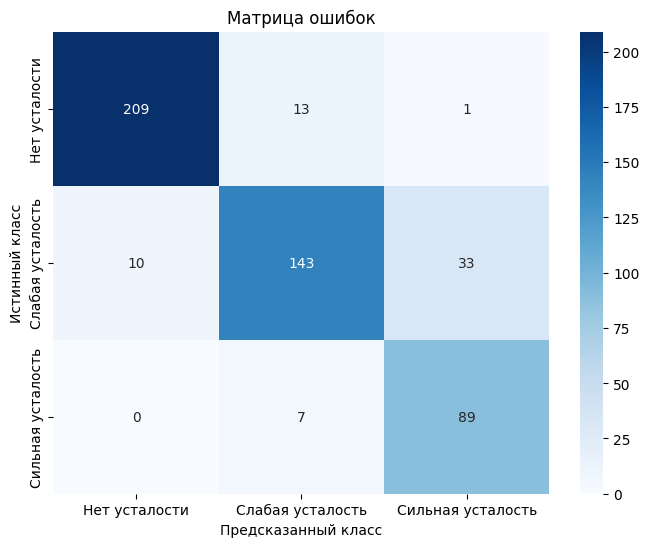

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cm = np.array([[209, 13, 1], [10, 143, 33], [0, 7, 89]])
class_names = ['Нет утолмения', 'Слабое утомление', 'Сильное утомление']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.show()